In [3]:
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    sys.path.insert(0, DRIVE_ROOT)
    # torchao 0.10 от ai-toolkit ломает peft 0.18 - выкорчёвываем
    get_ipython().system('pip uninstall -y torchao 2>/dev/null')
    get_ipython().system(f'pip install -q -r {DRIVE_ROOT}/requirements_inference.txt')
except ModuleNotFoundError:
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    sys.path.insert(0, DRIVE_ROOT)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")

EXP4_PROMPTS = [
    "minimalist coffee shop logo, circular icon, dark green, flat design",
    "tech startup logo, geometric hexagon, blue gradient, bold sans-serif",
    "bakery logo, wheat sheaf icon, warm brown, handcrafted artisan style",
    "fitness brand, lion silhouette, orange and black, bold geometric",
    "law firm logo, balanced scales, navy blue, serif elegant",
    "eco brand, leaf and water droplet, green and teal, clean minimal",
    "photography studio, aperture symbol, monochrome, sleek modern",
    "music label, vinyl record, purple gradient, retro modern",
    "medical clinic, cross and heartbeat, blue and white, professional",
    "restaurant, chef hat and fork, red and gold, classic",
    "real estate, house outline, dark blue, trustworthy minimal",
    "travel agency, compass rose, orange and navy, adventurous",
    "bookstore, open book, burgundy and gold, literary",
    "pet shop, paw print, teal and white, friendly rounded",
    "art gallery, abstract brush stroke, black and coral, creative",
    "yoga studio, lotus flower, lavender and white, serene",
    "gaming company, controller icon, dark purple neon, futuristic",
    "finance app, upward arrow chart, emerald green, trustworthy",
    "delivery service, lightning bolt package, yellow and dark grey, dynamic",
    "hair salon, scissors and comb, rose gold and black, premium",
    "construction company, hard hat, orange and black, bold solid",
    "organic farm, sun over field, green and yellow, natural",
    "coding bootcamp, terminal cursor, dark background cyan, tech",
    "wedding planner, interlinked rings, gold and ivory, elegant",
    "coffee roaster, steam cup bean, dark brown and copper, artisan",
    "surf shop, wave and sun, blue and sandy yellow, coastal",
    "candle brand, flame teardrop, warm amber and cream, cozy",
    "juice bar, orange slice splash, bright orange and green, fresh",
    "security firm, shield with lock, dark grey and blue, strong",
    "toy store, star balloon, bright multicolor, playful",
    "spa resort, lotus in water, soft teal and white, luxury",
    "architecture firm, geometric building outline, charcoal, minimal",
    "flower shop, stylized bloom, pink and green, feminine delicate",
    "wine brand, grape cluster, deep purple and gold, sophisticated",
    "cycling club, wheel spokes, red and white, sporty",
    "accounting firm, balance beam, navy and silver, precise",
    "art supplies, palette with brush, colorful abstract, creative",
    "dog grooming, dog face silhouette, brown and light blue, friendly",
    "language school, speech bubble globe, blue and orange, global",
    "printing shop, ink drop on paper, black and teal, clean",
    "e-commerce, shopping cart pixel, blue and yellow, digital",
    "event planning, balloon ribbon, purple and gold, festive",
    "dental clinic, tooth with sparkle, sky blue and white, clean",
    "vegan restaurant, leaf fork, green and beige, natural",
    "brewery, hops in circle, amber and dark brown, craft",
    "startup incubator, rocket in bulb, blue and green, innovative",
    "cloud storage, cloud with lock, grey and sky blue, tech",
    "insurance company, umbrella shield, dark blue and teal, protective",
    "fashion label, hanger silhouette, black and rose, chic",
    "children school, apple and pencil, red and yellow, friendly",
]
print(f"Loaded {len(EXP4_PROMPTS)} test prompts")



Mounted at /content/drive
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.8 MB/s eta 0:00:00
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma
Loaded 50 test prompts


In [4]:
import re
from pathlib import Path

import torch
from diffusers import StableDiffusionXLPipeline

# Поменять на ранг с лучшим FID из ноутбука 07
BEST_SDXL_LORA_DIR = f'{DRIVE_ROOT}/results/experiments/sdxl_r16'


def find_lora_safetensors(training_folder):
    folder = Path(training_folder)
    candidates = [p for p in folder.rglob('*.safetensors')
                  if not re.search(r'_\d{6,}\.safetensors$', p.name)]
    if not candidates:
        raise FileNotFoundError(f"No final LoRA safetensors under {training_folder}")
    canonical = [p for p in candidates if p.stem == p.parent.name]
    return str(canonical[0] if canonical else candidates[0])


out_dir = f'{DRIVE_ROOT}/results/experiments/exp4_sdxl_lora'
Path(out_dir).mkdir(parents=True, exist_ok=True)

weights = find_lora_safetensors(BEST_SDXL_LORA_DIR)
print(f"Loading LoRA: {weights}")

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
).to("cuda")
pipe.load_lora_weights(weights)
pipe.set_progress_bar_config(disable=True)

for i, prompt in enumerate(EXP4_PROMPTS):
    img = pipe(
        f"LOGOIMG {prompt}",
        negative_prompt="photorealistic, blurry, cluttered, complex background",
        generator=torch.Generator().manual_seed(42),
        guidance_scale=7.5,
        num_inference_steps=30,
        height=512, width=512,
    ).images[0]
    img.save(f"{out_dir}/prompt{i:02d}.png")

del pipe
torch.cuda.empty_cache()
print(f"SDXL LoRA: {len(EXP4_PROMPTS)} images -> {out_dir}")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading LoRA: /content/drive/MyDrive/liya_diploma/results/experiments/sdxl_r16/sdxl_logo_lora_r16/sdxl_logo_lora_r16.safetensors


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. Fo

SDXL LoRA: 50 images -> /content/drive/MyDrive/liya_diploma/results/experiments/exp4_sdxl_lora


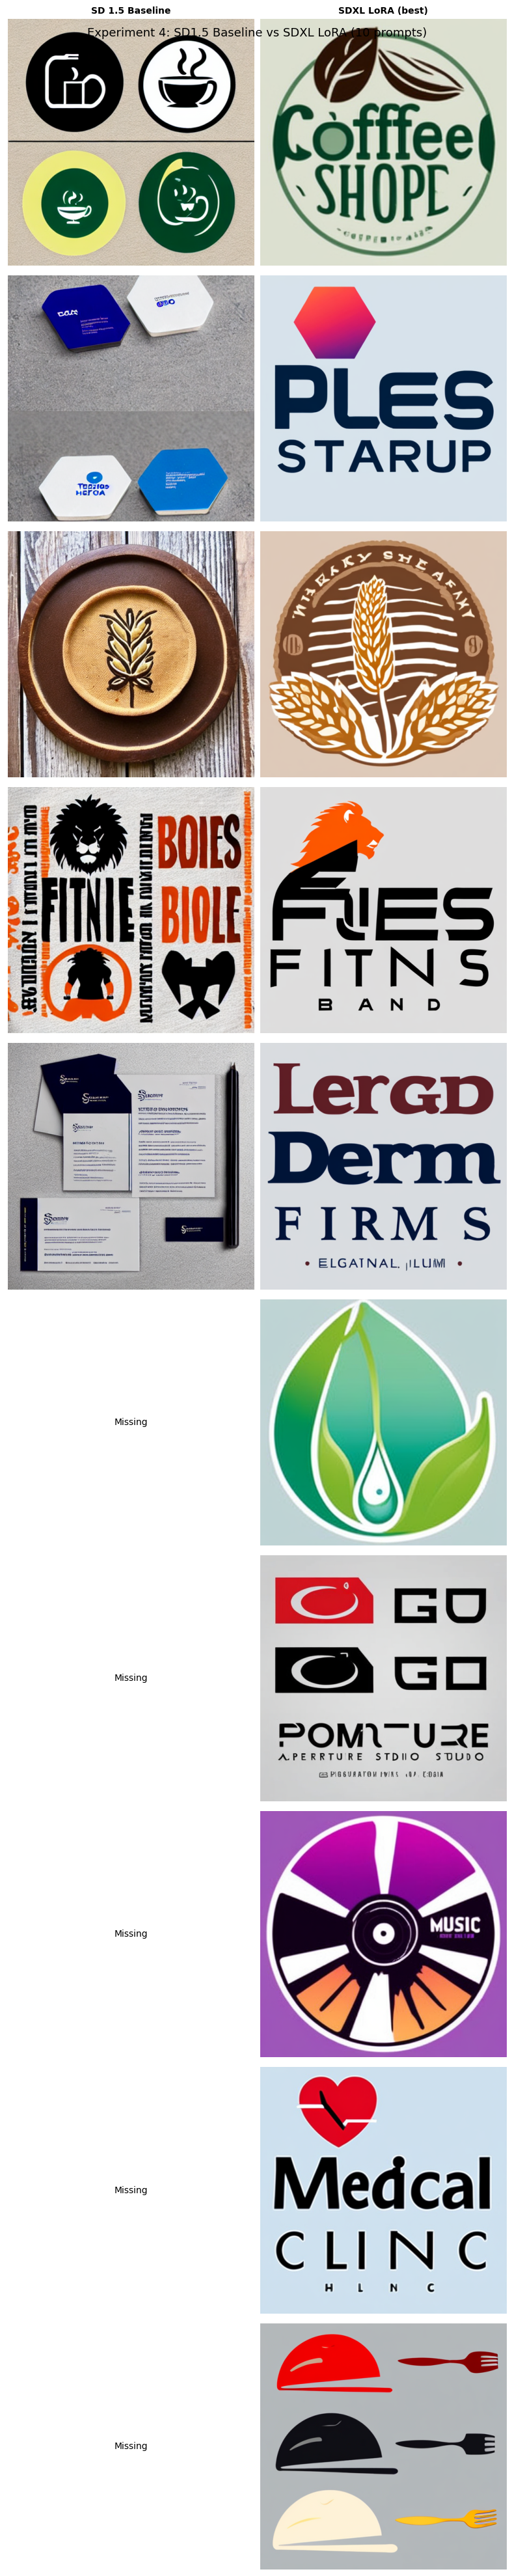

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

MODELS = {
    "SD 1.5 Baseline":  f'{DRIVE_ROOT}/results/experiments/sd15_baseline',
    "SDXL LoRA (best)": f'{DRIVE_ROOT}/results/experiments/exp4_sdxl_lora',
}

SHOW = list(range(10))
fig, axes = plt.subplots(len(SHOW), len(MODELS), figsize=(8, 40))

for row, idx in enumerate(SHOW):
    for col, (name, img_dir) in enumerate(MODELS.items()):
        suffix = "_v0" if name == "SD 1.5 Baseline" else ""
        img_path = f"{img_dir}/prompt{idx:02d}{suffix}.png"
        if Path(img_path).exists():
            axes[row, col].imshow(Image.open(img_path))
        else:
            axes[row, col].text(0.5, 0.5, "Missing", ha='center', va='center')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(name, fontsize=10, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(
                EXP4_PROMPTS[idx][:35], fontsize=6, rotation=0,
                labelpad=80, va='center',
            )

plt.suptitle("Experiment 4: SD1.5 Baseline vs SDXL LoRA (10 prompts)", fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/results/experiments/exp4_comparison_grid.png', dpi=150)
plt.show()
